In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

# Backprop in PyTorch

In lecture, we did backprop "by hand" on the following neural network:

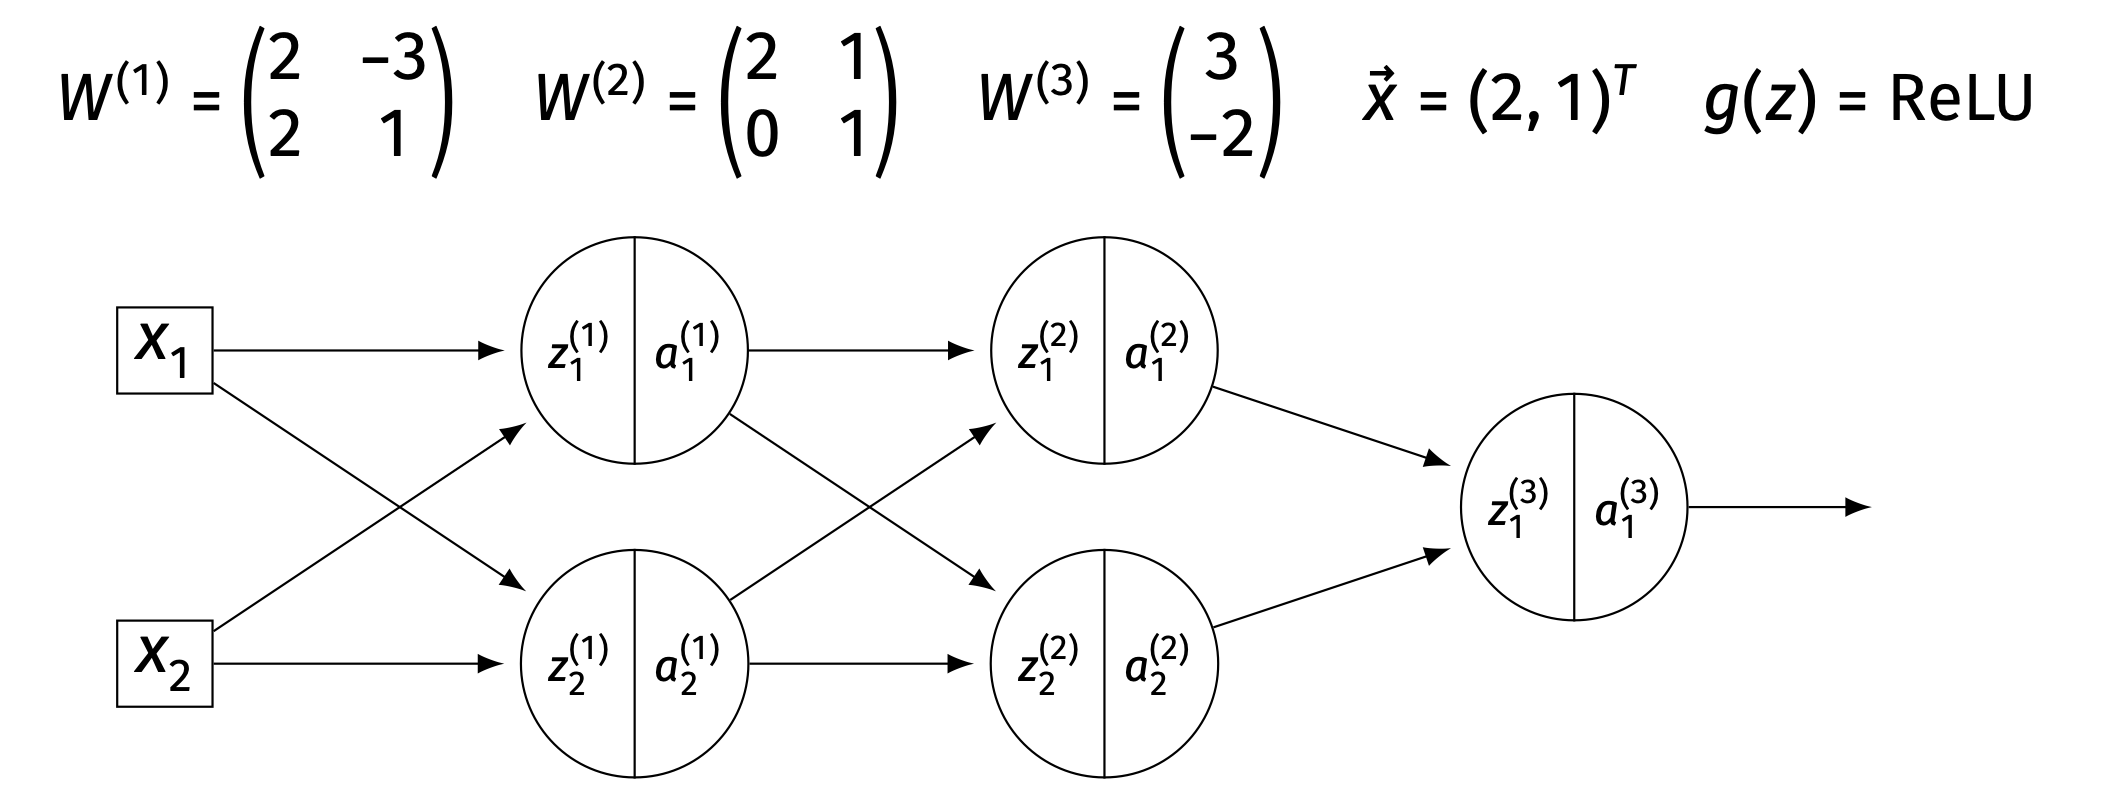

The picture below shows the results. The blue numbers come from the *forward* pass, when we evaluated the network on the input of $(2, 1)^T$. The red numbers are the various partial derivatives. For example, $\partial H / \partial W_{11}^{(1)}$ is 8.

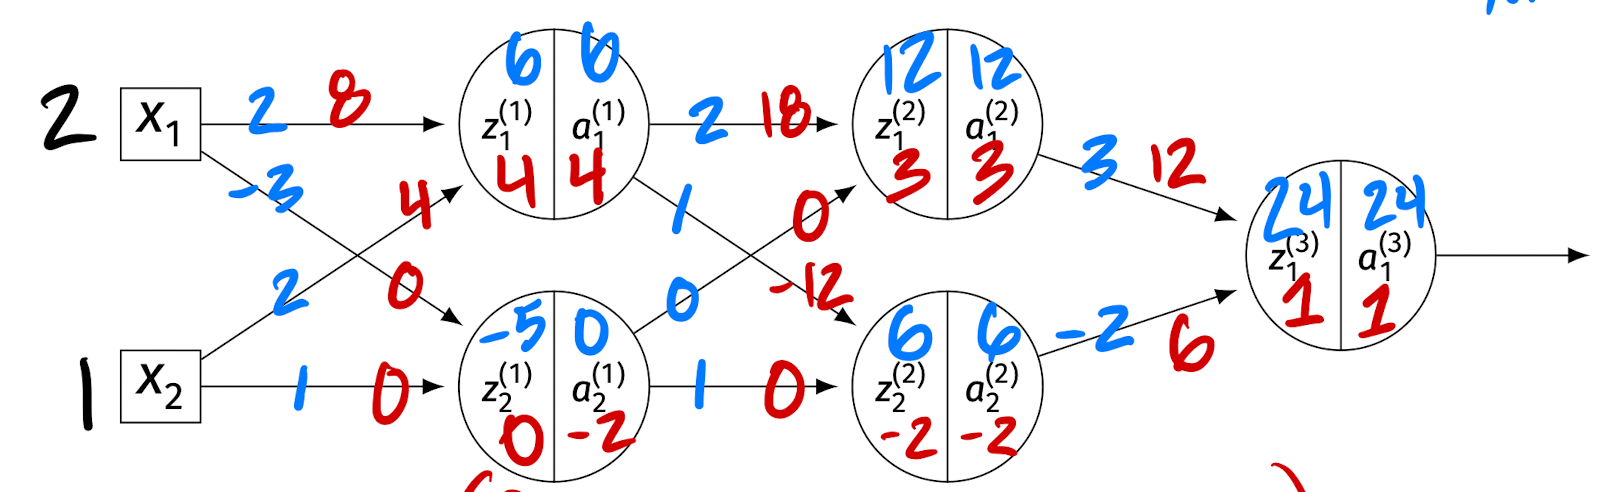

In practice, we never run backprop by hand: we use an *automatic differentiation* library, like `pytorch`, to do it for us.

Let's try to replicate the result above using PyTorch.

# Step 1) Constructing the network

First, we tell PyTorch about our NN. We do so by creating a class that inherits from `pytorch.nn.Module`. In the `__init__` method, we specify the architecture. In the `forward` method,
we tell PyTorch how to calculate the result of the network.

In [85]:
class ExampleNN(nn.Module):

    def __init__(self):
        super().__init__()

        # define the layers
        self.fully_connected_1 = nn.Linear(2, 2)
        self.fully_connected_2 = nn.Linear(2, 2)
        self.fully_connected_3 = nn.Linear(2, 1)

    def forward(self, x):
        # define how the network computes its result
        z_1 = self.fully_connected_1(x)
        a_1 = F.relu(z_1)
        z_2 = self.fully_connected_2(a_1)
        a_2 = F.relu(z_2)
        z_3 = self.fully_connected_3(a_2)

        # you don't normally need to save the intermediate
        # results, but we will for teaching purposes
        self.intermediate_results = {
            'z_1': z_1,
            'a_1': a_1,
            'z_2': z_2,
            'a_2': a_2,
            'z_3': z_3,
        }

        # the below makes sure that PyTorch saves dH/da and dH/dz; normally
        # you don't need to do this, but we will for teaching purposes
        for intermediate_result in self.intermediate_results.values():
            intermediate_result.retain_grad()

        return z_3

We then instantiate our network:

In [86]:
model = ExampleNN()

When we do so, PyTorch helpfully instantiates the network's weights randomly. We can see this by looking at a layer's weights and biases:

In [87]:
model.fully_connected_1.weight

Parameter containing:
tensor([[ 0.5210,  0.3173],
        [-0.1309,  0.4808]], requires_grad=True)

In [88]:
model.fully_connected_1.bias

Parameter containing:
tensor([-0.6408,  0.4988], requires_grad=True)

In order to replicate our example from lecture, we'll need to manually set the weights. (This isn't something we typically do in PyTorch -- the weights are usually *learned*).

The below sets the weights for each layer to be the same as in our lecture example. Note that PyTorch uses a different convention for the layout of the weight matrices, and so we need to *transpose* the matrices given in the slides when feeding them to PyTorch:

In [89]:
model.fully_connected_1.weight = nn.Parameter(
    torch.tensor([
        [2, -3],
        [2, 1]
    ], dtype=torch.float32).T
)

model.fully_connected_1.bias = nn.Parameter(torch.tensor([0, 0], dtype=torch.float32))

In [90]:
model.fully_connected_2.weight = nn.Parameter(
    torch.tensor([
        [2, 1],
        [0, 1]
    ], dtype=torch.float32).T
)

model.fully_connected_2.bias = nn.Parameter(torch.tensor([0, 0], dtype=torch.float32))

In [91]:
model.fully_connected_3.weight = nn.Parameter(
    torch.tensor([
        [3],
        [-2]
    ], dtype=torch.float32).T
)

model.fully_connected_3.bias = nn.Parameter(torch.tensor([0], dtype=torch.float32))

## Step 2) Forward pass

In the forward pass of backprop, we evaluate the network. Doing so is easy in PyTorch. In our example, we evaluated the network on $(2, 1)^T$. To do that now, we defined a tensor of these two numbers (being careful to make them floats, and not integers) and call our `model` on it:

In [92]:
result = model(torch.tensor([2.0, 1.0]))
result

tensor([24.], grad_fn=<ViewBackward0>)

If we compare this to the result we got in lecture, we see that they are the same (look at the blue number we wrote on the output node -- that is the output of the network).

We can also check that the intermediate results agree:

In [93]:
model.intermediate_results

{'z_1': tensor([ 6., -5.], grad_fn=<ViewBackward0>),
 'a_1': tensor([6., 0.], grad_fn=<ReluBackward0>),
 'z_2': tensor([12.,  6.], grad_fn=<ViewBackward0>),
 'a_2': tensor([12.,  6.], grad_fn=<ReluBackward0>),
 'z_3': tensor([24.], grad_fn=<ViewBackward0>)}

## Step 3) Backward pass

Now we need to run the backward pass of backprop. In lecture, we did this by hand, first applying to backprop rules to the output node to compute $\partial H / \partial z_1^{(3)}$, then using that to compute $\partial H / \partial W_{11}^{(3)}$ and $\partial H / \partial W_{12}^{(3)}$, and so on, propagating the derivatives backwards.

Of course, PyTorch can carry out this algorithm for us. It is as simple as:

In [94]:
result.backward()

Note that we called `.backward()` on `result`, not the `model`! This might seem strange, but it turns out that `result` isn't simply the number "24": it is a `pytorch.tensor` object that stores not just the number, but also all of the steps that went into computing that number. When we call `.backward()`, PyTorch traces backwards through that history and performs backpropagation, just as we did in lecture.

Let's check to make sure that PyTorch got the same results as us. To do so, we can look at the `.grad` attribute of our weights in each layer:

In [100]:
model.fully_connected_1.weight.grad

tensor([[8., 4.],
        [0., 0.]])

In [101]:
model.fully_connected_2.weight.grad

tensor([[ 18.,   0.],
        [-12.,   0.]])

In [102]:
model.fully_connected_3.weight.grad

tensor([[12.,  6.]])

Remember: PyTorch uses the opposite convention, and these matrices are transposed compared to ours.

We can also check that the $\partial H/ \partial z$ and $\partial H/\partial a$ derivatives are as expected. Normally, PyTorch discards this information because it's not directly used to train the network; we made sure it was kept by calling `.retain_grad()` in the `.forward()` method when we defined our network:

In [107]:
for key, intermediate_result in model.intermediate_results.items():
    print(key)
    print('-'*len(key))
    print(intermediate_result.grad)
    print()

z_1
---
tensor([4., 0.])

a_1
---
tensor([ 4., -2.])

z_2
---
tensor([ 3., -2.])

a_2
---
tensor([ 3., -2.])

z_3
---
tensor([1.])

